Fetching weather data from Open-Meteo...

--- Target Variable Summaries ---
Train:
count    11520.000000
mean        71.811144
std         39.788051
min          9.420000
25%         38.107500
50%         57.390000
75%        105.875000
max        183.640000
Name: Total Load (MW), dtype: float64

Validation:
count    2928.000000
mean       76.603320
std        36.182472
min        13.450000
25%        43.125000
50%        69.980000
75%       106.292500
max       173.510000
Name: Total Load (MW), dtype: float64

Test:
count    2688.000000
mean       57.143531
std        34.697100
min         0.000000
25%        34.050000
50%        46.105000
75%        75.527500
max       171.430000
Name: Total Load (MW), dtype: float64

Training Optimized SVR on 11520 hours...
Predicting on Test Set (2688 hours)...

 SVR (WITH WEATHER) PERFORMANCE
MAE  : 10.2409
RMSE : 16.2661
R²   : 0.7801


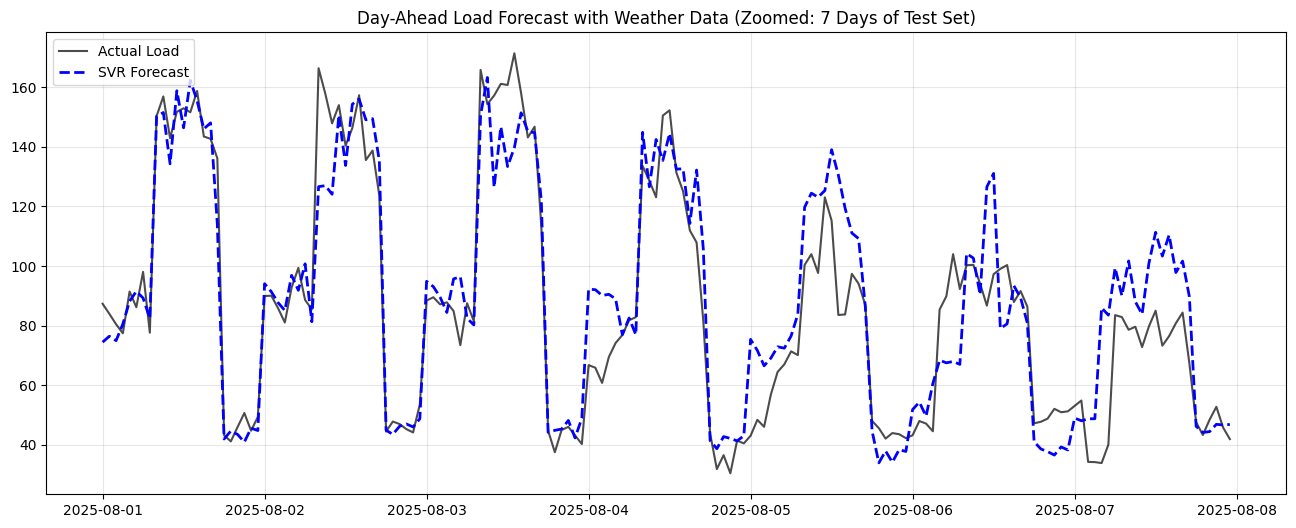

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
import requests

warnings.filterwarnings("ignore")

df = pd.read_csv(r"C:\Users\Ayush\Desktop\surge\kuppam\Hourly_Data_220kV.csv") 

df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df = df.dropna(subset=['Datetime'])
df = df.drop_duplicates(subset=['Datetime'], keep='first')
df.set_index('Datetime', inplace=True)
df.index = df.index.tz_localize(None) 
df['Total Load (MW)'] = df['Total Load (MW)'].astype(str).str.replace(',', '')
df['Total Load (MW)'] = pd.to_numeric(df['Total Load (MW)'], errors='coerce')
df = df.asfreq('1H').ffill()

print("Fetching weather data from Open-Meteo...")
url = (
    "https://archive-api.open-meteo.com/v1/archive"
    "?latitude=12.75"
    "&longitude=78.34"
    "&start_date=2023-12-01"
    "&end_date=2025-11-20"
    "&hourly=temperature_2m,relative_humidity_2m,"
    "precipitation,cloud_cover,wind_speed_10m"
)

wdata = requests.get(url).json()
weather = pd.DataFrame(wdata["hourly"])
weather["Datetime"] = pd.to_datetime(weather["time"])
weather["Datetime"] = weather["Datetime"].dt.tz_localize(None)
weather.set_index("Datetime", inplace=True)
weather = weather.sort_index()

weather.drop(columns=['time'], inplace=True, errors='ignore')
df = df.join(weather, how='left')
df = df.ffill()

df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek
df['Month'] = df.index.month
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
df['Load_24h_Ago'] = df['Total Load (MW)'].shift(24) 
df['Load_48h_Ago'] = df['Total Load (MW)'].shift(48) 
df['Load_168h_Ago'] = df['Total Load (MW)'].shift(168) 

df['temp_sq'] = df['temperature_2m']**2
df['rain_flag'] = (df['precipitation'] > 0).astype(int)

df = df.dropna()

train = df[df.index < '2025-04-01'].copy()
val = df[(df.index >= '2025-04-01') & (df.index < '2025-08-01')].copy()
test = df[df.index >= '2025-08-01'].copy()

features = [
    'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 
    'Load_24h_Ago', 'Load_48h_Ago', 'Load_168h_Ago',
    'temp_sq', 'rain_flag', 'temperature_2m', 
    'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m'
]

X_train = train[features]
y_train = train['Total Load (MW)']

X_val = val[features]
y_val = val['Total Load (MW)']

X_test = test[features]
y_test = test['Total Load (MW)']

print("\n--- Target Variable Summaries ---")
print("Train:")
print(y_train.describe())
print("\nValidation:")
print(y_val.describe())
print("\nTest:")
print(y_test.describe())

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val) 
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

print(f"\nTraining Optimized SVR on {len(X_train)} hours...")
svr_model = SVR(kernel='rbf', C=1, gamma=0.1, epsilon=0.01)
svr_model.fit(X_train_scaled, y_train_scaled)

print(f"Predicting on Test Set ({len(X_test)} hours)...")
y_pred_scaled = svr_model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n SVR (WITH WEATHER) PERFORMANCE")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

zoom_hours = 24 * 7
plt.figure(figsize=(16, 6))
plt.plot(test.index[:zoom_hours], y_test.iloc[:zoom_hours], color='black', alpha=0.7, label='Actual Load')
plt.plot(test.index[:zoom_hours], y_pred[:zoom_hours], color='blue', linestyle='--', linewidth=2, label='SVR Forecast')
plt.title('Day-Ahead Load Forecast with Weather Data (Zoomed: 7 Days of Test Set)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# read
df = pd.read_csv(r"C:\Users\Ayush\Desktop\surge\kuppam\Hourly_Data_220kV.csv") 

# preprocess
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df = df.dropna(subset=['Datetime'])
df = df.drop_duplicates(subset=['Datetime'], keep='first')
df.set_index('Datetime', inplace=True)
df['Total Load (MW)'] = df['Total Load (MW)'].astype(str).str.replace(',', '')
df['Total Load (MW)'] = pd.to_numeric(df['Total Load (MW)'], errors='coerce')
df = df.asfreq('1H').ffill()

# features
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek
df['Month'] = df.index.month
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
df['Load_24h_Ago'] = df['Total Load (MW)'].shift(24) # 1 day
df['Load_48h_Ago'] = df['Total Load (MW)'].shift(48) # 2 days
df['Load_168h_Ago'] = df['Total Load (MW)'].shift(168) # 1 week 
df = df.dropna()

# split 
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

# listing all features
features = ['Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'Load_24h_Ago', 'Load_48h_Ago', 'Load_168h_Ago']

X_train = train[features]
y_train = train['Total Load (MW)']
X_test = test[features]
y_test = test['Total Load (MW)']

# to scale the data as SVR needs scaled data for regression
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# train
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()


# training params standard values
svr_model = SVR(kernel='rbf', C=1, gamma=0.1, epsilon=0.01)
svr_model.fit(X_train_scaled, y_train_scaled)

# prediction
y_pred_scaled = svr_model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()


#results
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n SVR (WITHOUT WEATHER) PERFORMANCE")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


 SVR (WITHOUT WEATHER) PERFORMANCE
MAE  : 9.4401
RMSE : 15.2777
R²   : 0.8341


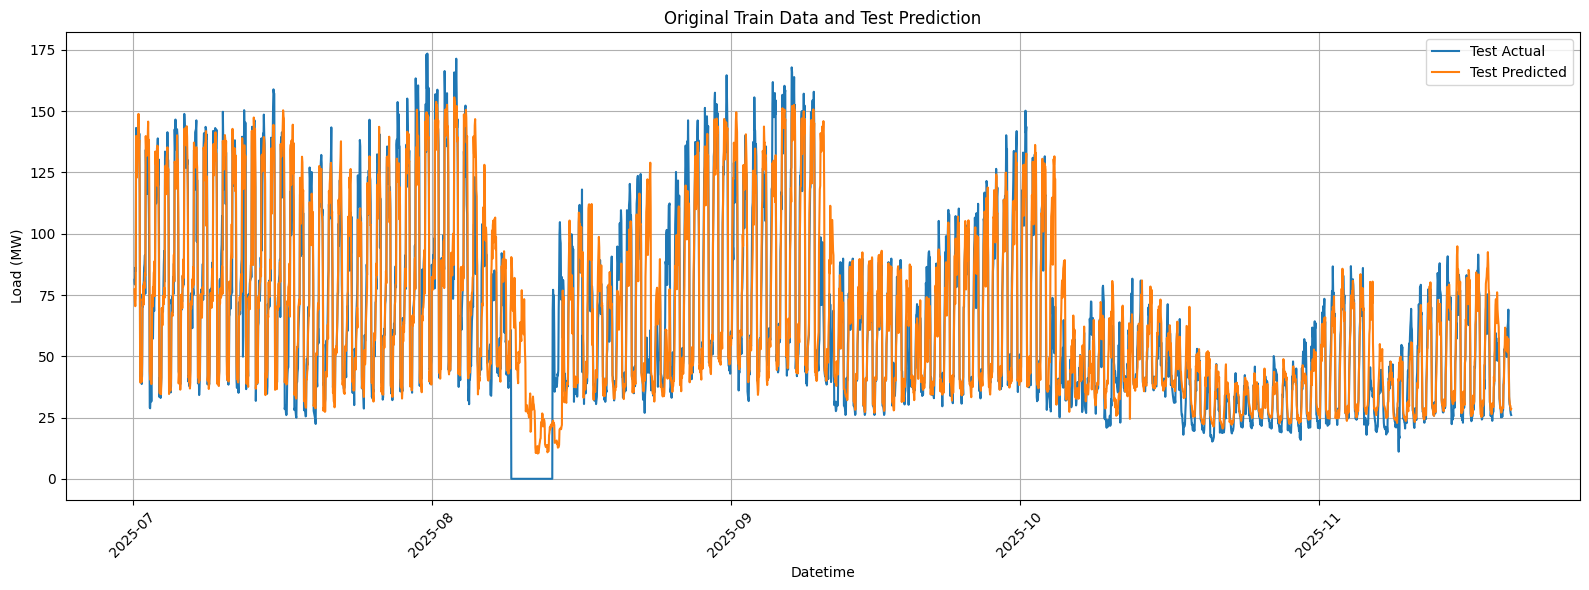

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

# plt.plot(
#     train.index,
#     train['Total Load (MW)'],
#     label='Train (Original)'
# )

plt.plot(
    test.index,
    test['Total Load (MW)'],
    label='Test Actual'
)

plt.plot(
    test.index,
    y_pred,
    label='Test Predicted'
)

plt.xlabel('Datetime')
plt.ylabel('Load (MW)')
plt.title('Original Train Data and Test Prediction')

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
import pandas as pd

df = pd.read_excel(r"../data/Hourly_Data_220kV.xlsx")

df['Datetime'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time'].astype(str),
    errors='coerce'
)

df = df.dropna(subset=['Datetime'])
df = df.drop_duplicates(subset=['Datetime'], keep='first')

df.set_index('Datetime', inplace=True)

full_range = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='1H'
)

missing = full_range.difference(df.index)

print("Total missing timestamps:", len(missing))

if len(missing) == 0:
    print("No missing timestamps found")
else:
    print("\nMissing timestamps:")
    print(missing)

    missing_df = pd.DataFrame({'Missing': missing})

    missing_df['Gap'] = (
        missing_df['Missing'].diff() != pd.Timedelta(hours=1)
    ).cumsum()

    gap_summary = missing_df.groupby('Gap').agg(
        Start=('Missing', 'first'),
        End=('Missing', 'last'),
        Count=('Missing', 'count')
    )

    print("\nMissing gaps:")
    print(gap_summary)

Total missing timestamps: 25

Missing timestamps:
DatetimeIndex(['2024-09-14 23:00:00', '2025-05-27 00:00:00',
               '2025-05-27 01:00:00', '2025-05-27 02:00:00',
               '2025-05-27 03:00:00', '2025-05-27 04:00:00',
               '2025-05-27 05:00:00', '2025-05-27 06:00:00',
               '2025-05-27 07:00:00', '2025-05-27 08:00:00',
               '2025-05-27 09:00:00', '2025-05-27 10:00:00',
               '2025-05-27 11:00:00', '2025-05-27 12:00:00',
               '2025-05-27 13:00:00', '2025-05-27 14:00:00',
               '2025-05-27 15:00:00', '2025-05-27 16:00:00',
               '2025-05-27 17:00:00', '2025-05-27 18:00:00',
               '2025-05-27 19:00:00', '2025-05-27 20:00:00',
               '2025-05-27 21:00:00', '2025-05-27 22:00:00',
               '2025-05-27 23:00:00'],
              dtype='datetime64[ns]', freq=None)

Missing gaps:
                  Start                 End  Count
Gap                                               
1   2024-09-1

C:\Users\Ayush\AppData\Local\Temp\ipykernel_56276\2328017851.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(
